In [ ]:
!pip install -q transformers accelerate peft bitsandbytes
!pip install -q razdel pymorphy2
!pip install -q scikit-learn scipy matplotlib seaborn

Приклеим гуглдиск, чтобы не пересохранять все по куче раз

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install pymorphy3

теперь импортируем все возможное и невозможное

In [ ]:
import os, re, glob, gc, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from scipy.spatial.distance import cosine
from scipy.stats import entropy
from sklearn.preprocessing import StandardScaler
import razdel
import pymorphy3
import torch

зафиксируем сид для воспроизводимости


In [ ]:
warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [ ]:
morph = pymorphy3.MorphAnalyzer()

Возьмем тексты, которые мы уже скачали: Толстого, Булгакова и Акунина.

Вот ссылка на гугл-папку: лучше перед исполнением скачать тексты себе на диск, чтобы все исполнялось все хорошо и сразу же сохранялось.

https://drive.google.com/drive/folders/1Hqbm3w4Nsu8b7Rh1iSW_d1YdEkuiRPTG?usp=sharing

In [ ]:
BASE_DIR = '/content/drive/MyDrive/texts_project'
OUT_DIR = os.path.join(BASE_DIR, 'output')
MODEL_DIR = os.path.join(OUT_DIR, 'models')
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

Возьмем маленькую мультиязычную модельку, которая умеет генерировать тексты

In [ ]:
MODEL_NAME = 'facebook/xglm-4.5B'

Возьмем стоп-слова и части речи

In [ ]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
FUNC_WORDS = set(stopwords.words('russian'))

In [ ]:
TRACKED_FW = ['и','в','на','не','что','с','но','а','как','же']

In [ ]:
TRACKED_POS = ['NOUN','VERB','ADJF','ADVB','PREP','CONJ','PRCL','NPRO','INFN','NUMR']

Напишем функцию для загрузки текстов по авторам

In [ ]:
def load_texts_by_author(base_dir):
    authors = {}
    for folder in sorted(os.listdir(base_dir)):
        path = os.path.join(base_dir, folder)
        if not os.path.isdir(path) or folder == 'output':
            continue
        texts = []
        for fp in sorted(glob.glob(os.path.join(path, '*.txt'))):
            with open(fp, 'r', encoding='cp1251') as f:
                content = f.read().strip()
            if content:
                texts.append({'file': os.path.basename(fp), 'text': content})
        if texts:
            authors[folder] = texts
    return authors
authors_data = load_texts_by_author(BASE_DIR)

Посмотрим, сколько у нас символов в текстах и документах (я взяла большие тексты, поэтому самих файлов маловато, но на таких объемах ресерч на копирование стиля тоже есть). Плюс, сильно больше не получалось из-за колаба и его ограничений на длину сессии

In [ ]:
print(f'Authors found: {len(authors_data)}\n')
row = '{:<30}{:>6}{:>14}{:>14}{:>12}{:>12}'
print(row.format('Author','Files','Total chars','Mean chars','Min','Max'))
print('-' * 90)
for author, texts in authors_data.items():
    lens = [len(t['text']) for t in texts]
    print(row.format(
        author, len(texts),
        f'{sum(lens):,}', f'{int(np.mean(lens)):,}',
        f'{min(lens):,}', f'{max(lens):,}',
    ))

Authors found: 3

Author                         Files   Total chars    Mean chars         Min         Max
------------------------------------------------------------------------------------------
akunin                             2       702,215       351,107     333,787     368,428
bulgakov                           3       833,601       277,867     139,505     479,138
tolstoy                            2     2,038,272     1,019,136     405,239   1,633,033


In [ ]:
def tokenize_words(text):
    return [t.text.lower() for t in razdel.tokenize(text)
            if re.search(r'[а-яёa-z]', t.text, re.I)]

In [ ]:
def tokenize_sentences(text):
    return [s.text for s in razdel.sentenize(text)]

Соберем функцию для подсчета метрик

In [ ]:
def compute_metrics(text, pos_word_limit=2000):
    words = tokenize_words(text)
    sents = tokenize_sentences(text)
    if len(words) < 20 or len(sents) < 3:
        return None
    m = {}
    wl = np.array([len(w) for w in words])
    m['mean_word_len']  = wl.mean()
    m['std_word_len']   = wl.std()
    sl = np.array([len(tokenize_words(s)) for s in sents])
    m['mean_sent_len']  = sl.mean()
    m['std_sent_len']   = sl.std()
    vocab = set(words)
    freq = Counter(words)
    N = len(words)
    V = len(vocab)
    m['ttr'] = V / N
    hapax = sum(1 for c in freq.values() if c == 1)
    m['hapax_ratio'] = hapax / V if V else 0
    spec = Counter(freq.values())
    M2 = sum(i * i * v for i, v in spec.items())
    m['yules_k'] = 10_000 * (M2 - N) / (N * N) if N > 1 else 0
    m['simpsons_d'] = 1 - sum(n * (n - 1) for n in freq.values()) / (N * (N - 1)) if N > 1 else 0
    probs = np.array(list(freq.values())) / N
    m['word_entropy'] = float(entropy(probs))
    fw_count = sum(1 for w in words if w in FUNC_WORDS)
    m['func_word_ratio'] = fw_count / N
    for fw in TRACKED_FW:
        m[f'fw_{fw}'] = freq.get(fw, 0) / N
    total_chars = max(len(text), 1)
    for ch, label in [(',','comma'),('.','period'),('!','excl'),
                      ('?','question'),('—','dash'),(';','semi'),
                      (':','colon'),('«','lquote')]:
        m[f'p_{label}'] = text.count(ch) / total_chars
    pos_cnt = Counter()
    for w in words[:pos_word_limit]:
        tag = morph.parse(w)[0].tag.POS
        pos_cnt[tag or 'UNK'] += 1
    tot = sum(pos_cnt.values()) or 1
    for pos in TRACKED_POS:
        m[f'pos_{pos}'] = pos_cnt.get(pos, 0) / tot
    clauses = re.split(r'[,;:.!?—]', text)
    cl = [len(tokenize_words(c)) for c in clauses if c.strip()]
    m['mean_clause_len'] = np.mean(cl) if cl else 0
    return m

In [ ]:
def _vectors(profiles, feature_names):
    """Stack metric dicts into a matrix (rows = profiles)."""
    return np.array([[p.get(f, 0) for f in feature_names] for p in profiles])

In [ ]:
def burrows_delta(vec_a, vec_b, means, stds):
    """Classic Burrows' Delta between two z-scored vectors."""
    za = (vec_a - means) / (stds + 1e-12)
    zb = (vec_b - means) / (stds + 1e-12)
    return np.mean(np.abs(za - zb))


In [ ]:
def cosine_delta(vec_a, vec_b):
    d = cosine(vec_a, vec_b)
    return d if np.isfinite(d) else 1.0

In [ ]:
def kilgarriff_chi2(words_a, words_b, n_top=500):
    """Kilgarriff's chi-squared on the n_top most frequent words."""
    fa, fb = Counter(words_a), Counter(words_b)
    na, nb = len(words_a), len(words_b)
    common = (fa + fb).most_common(n_top)
    chi2 = 0.0
    for word, _ in common:
        ra = fa[word] / na
        rb = fb[word] / nb
        pooled = (fa[word] + fb[word]) / (na + nb)
        if pooled > 0:
            chi2 += (ra - rb) ** 2 / pooled
    return chi2

In [ ]:
author_full = {}
for author, texts in authors_data.items():
    author_full[author] = '\n\n'.join(t['text'] for t in texts)

author_names = sorted(author_full.keys())

In [ ]:
author_metrics = {}
for a in author_names:
    m = compute_metrics(author_full[a])
    if m is None:
        print(f'WARNING: text too short for {a}')
    author_metrics[a] = m


In [ ]:
feature_names = sorted(author_metrics[author_names[0]].keys())


Посчитаем метрики для наших текстов

In [ ]:
df_metrics = pd.DataFrame(author_metrics).T
df_metrics.index.name = 'author'
print('=== Per-author stylometric profiles ===')
print(df_metrics.round(5).to_string())


=== Per-author stylometric profiles ===
          mean_word_len  std_word_len  mean_sent_len  std_sent_len      ttr  hapax_ratio   yules_k  simpsons_d  word_entropy  func_word_ratio     fw_и     fw_в    fw_на    fw_не   fw_что     fw_с    fw_но     fw_а   fw_как    fw_же  p_comma  p_period   p_excl  p_question   p_dash   p_semi  p_colon  p_lquote  pos_NOUN  pos_VERB  pos_ADJF  pos_ADVB  pos_PREP  pos_CONJ  pos_PRCL  pos_NPRO  pos_INFN  pos_NUMR  mean_clause_len
author                                                                                                                                                                                                                                                                                                                                                                                                                                   
akunin          5.59140       3.22639       10.13893       7.63056  0.26760      0.65197  36.78228     0.996

In [ ]:
mat = _vectors([author_metrics[a] for a in author_names], feature_names)
means = mat.mean(axis=0)
stds  = mat.std(axis=0)

In [ ]:
n = len(author_names)
delta_matrix  = np.zeros((n, n))
cosine_matrix = np.zeros((n, n))
chi2_matrix   = np.zeros((n, n))

In [ ]:
for i in range(n):
    for j in range(n):
        delta_matrix[i, j] = burrows_delta(mat[i], mat[j], means, stds)
        cosine_matrix[i, j] = cosine_delta(mat[i], mat[j])
        wa = tokenize_words(author_full[author_names[i]])
        wb = tokenize_words(author_full[author_names[j]])
        chi2_matrix[i, j] = kilgarriff_chi2(wa, wb)

In [ ]:
for title, matrix in [("Burrows' Delta", delta_matrix),
                      ("Cosine distance", cosine_matrix),
                      ("Kilgarriff χ²", chi2_matrix)]:
    print(f'\n=== {title} ===')
    df = pd.DataFrame(matrix, index=author_names, columns=author_names)
    print(df.round(4).to_string())


=== Burrows' Delta ===
          akunin  bulgakov  tolstoy
akunin    0.0000    1.2293   1.7911
bulgakov  1.2293    0.0000   1.5727
tolstoy   1.7911    1.5727   0.0000

=== Cosine distance ===
          akunin  bulgakov  tolstoy
akunin    0.0000    0.0057   0.0044
bulgakov  0.0057    0.0000   0.0070
tolstoy   0.0044    0.0070   0.0000

=== Kilgarriff χ² ===
          akunin  bulgakov  tolstoy
akunin    0.0000    0.1769   0.2549
bulgakov  0.1772    0.0000   0.2031
tolstoy   0.2552    0.2031   0.0000


Отщипнем от текстов кусочки которые мы будем давать во фью-шот и кусочки, которые мы будем использовать как тест

In [ ]:
FEW_SHOT_CHARS = 2000
TEST_CHARS = 3000

In [ ]:
splits = {}  # author -> {train, test, few_shot}

In [ ]:
for author in author_names:
    full = author_full[author]
    total = len(full)
    if total < FEW_SHOT_CHARS + TEST_CHARS + 1000:
        # if text is short, use proportional splits
        fs = int(total * 0.15)
        ts = int(total * 0.20)
    else:
        fs = FEW_SHOT_CHARS
        ts = TEST_CHARS
    few_shot = full[:fs]
    test = full[-ts:]
    train = full[fs:-ts]
    splits[author] = {
        'train':    train,
        'test':     test,
        'few_shot': few_shot,
    }
    print(f'{author:30s}  train={len(train):>7,}  test={len(test):>6,}  few_shot={len(few_shot):>5,} chars')

akunin                          train=697,217  test= 3,000  few_shot=2,000 chars
bulgakov                        train=828,605  test= 3,000  few_shot=2,000 chars
tolstoy                         train=2,033,274  test= 3,000  few_shot=2,000 chars


Теперь заведем квантованный конфиг для загрузки модельки

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

In [ ]:
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)


Загрузим модельку

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

config.json:   0%|          | 0.00/577 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/448 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.03M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/276 [00:00<?, ?B/s]

In [ ]:
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quant_config,
    device_map='auto',
)
base_model.config.use_cache = True


model.safetensors:   0%|          | 0.00/10.2G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/772 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

In [ ]:
print(f'Max position embeddings: {base_model.config.max_position_embeddings}')

Max position embeddings: 2048


In [ ]:
MAX_POS = base_model.config.max_position_embeddings
GEN_TOKENS = 500

Заведем словарик для фьюшотных генераций

In [ ]:
few_shot_generated = {}

Нагенерируем, передавая фьюшотный кусок и требуя продолжения в том же стиле (результаты сохранились в моей гугл папке), видим, что получилось не очень: нейронка нас даже не очень понимает...

In [ ]:
for author in author_names:
    chunk = splits[author]['few_shot']
    prompt = (
        chunk.strip() + '\n\n'
        'Напиши рассказ в том же стиле:\n\n'
    )
    enc = tokenizer(prompt, return_tensors='pt', truncation=False)
    input_ids = enc['input_ids']
    max_prompt = MAX_POS - GEN_TOKENS
    if input_ids.shape[1] > max_prompt:
        input_ids = input_ids[:, -max_prompt:]
    input_ids = input_ids.to(base_model.device)
    with torch.no_grad():
        out = base_model.generate(
            input_ids,
            max_new_tokens=GEN_TOKENS,
            do_sample=True,
            temperature=0.85,
            top_p=0.92,
            repetition_penalty=1.15,
        )
    generated_ids = out[0, input_ids.shape[1]:]
    text_out = tokenizer.decode(generated_ids, skip_special_tokens=True)
    few_shot_generated[author] = text_out
    print(f'\n--- {author} (few-shot, {len(text_out)} chars) ---')
    print(text_out[:500], '...\n')


--- akunin (few-shot, 34 chars) ---
Фантастика. Боевая фантастика (57) ...


--- bulgakov (few-shot, 91 chars) ---
«Роковой день» — роман охватывает целый период истории России конца XIX – начала XX века... ...


--- tolstoy (few-shot, 1888 chars) ---
Оглавление 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150  ...



In [ ]:
import json
with open(os.path.join(OUT_DIR, 'few_shot_generated.json'), 'w', encoding='utf-8') as f:
    json.dump(few_shot_generated, f, ensure_ascii=False, indent=2)

In [ ]:
print('Few-shot texts saved.')

Few-shot texts saved.


In [ ]:
few_shot_metrics = {}
test_metrics = {}


In [ ]:
for author in author_names:
    test_metrics[author] = compute_metrics(splits[author]['test'])
    fs_m = compute_metrics(few_shot_generated[author])
    if fs_m is None:
        print(f'WARNING: few-shot text too short for {author}, metrics skipped')
    few_shot_metrics[author] = fs_m

print('\nDistance few-shot → original test chunk (per author):')
print(f'{"Author":<30} {"Burrows δ":>12} {"Cosine":>12}')
print('-' * 56)
for author in author_names:
    if few_shot_metrics[author] is None or test_metrics[author] is None:
        print(f'{author:<30} {"n/a":>12} {"n/a":>12}')
        continue
    va = np.array([test_metrics[author].get(f, 0) for f in feature_names])
    vb = np.array([few_shot_metrics[author].get(f, 0) for f in feature_names])
    bd = burrows_delta(va, vb, means, stds)
    cd = cosine_delta(va, vb)
    print(f'{author:<30} {bd:>12.4f} {cd:>12.4f}')

# persist
with open(os.path.join(OUT_DIR, 'few_shot_metrics.json'), 'w') as f:
    json.dump(few_shot_metrics, f, ensure_ascii=False, indent=2)
with open(os.path.join(OUT_DIR, 'test_metrics.json'), 'w') as f:
    json.dump(test_metrics, f, ensure_ascii=False, indent=2)

print('\nMetrics saved.')


Distance few-shot → original test chunk (per author):
Author                            Burrows δ       Cosine
--------------------------------------------------------
akunin                                  n/a          n/a
bulgakov                                n/a          n/a
tolstoy                                 n/a          n/a

Metrics saved.


Даже метрики не можем посчитать, получились слишком маленькие тексты

Теперь заводим лору:

In [ ]:
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling
from datasets import Dataset

In [ ]:
BLOCK_SIZE = 512
EPOCHS = 3
LR = 2e-4
BATCH = 1
GRAD_ACC = 8

In [ ]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=['q_proj', 'v_proj'],
    bias='none',
    task_type=TaskType.CAUSAL_LM,
)

In [ ]:
def build_dataset(text, tokenizer, block_size=BLOCK_SIZE):
    ids = tokenizer(text, truncation=False, add_special_tokens=False)['input_ids']
    blocks = []
    for i in range(0, len(ids) - block_size + 1, block_size):
        blocks.append({'input_ids': ids[i:i + block_size]})
    if not blocks:
        pad_len = block_size - len(ids)
        blocks.append({'input_ids': ids + [tokenizer.pad_token_id] * pad_len})
    return Dataset.from_list(blocks)

In [ ]:
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

убираем модельку которую загрузили и чистим куду

In [ ]:
del base_model
torch.cuda.empty_cache()
gc.collect()

7836

Теперь тюним три модельки, по одному варианту для каждого автора:

In [ ]:
for author in author_names:
    print(f'\n{"="*60}')
    print(f'Fine-tuning for: {author}')
    print(f'{"="*60}')
    save_path = os.path.join(MODEL_DIR, author.replace(' ', '_'))
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=quant_config,
        device_map='auto',
    )
    model.config.use_cache = False
    model = prepare_model_for_kbit_training(model)
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()
    ds = build_dataset(splits[author]['train'], tokenizer)
    print(f'Training blocks: {len(ds)}')
    args = TrainingArguments(
        output_dir=os.path.join(OUT_DIR, 'checkpoints', author.replace(' ', '_')),
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH,
        gradient_accumulation_steps=GRAD_ACC,
        learning_rate=LR,
        fp16=True,
        logging_steps=max(1, len(ds) // (BATCH * GRAD_ACC * 5)),
        save_strategy='no',
        report_to='none',
        warmup_ratio=0.05,
    )
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=ds,
        data_collator=data_collator,
    )
    trainer.train()
    # save adapter to Google Drive
    model.save_pretrained(save_path)
    tokenizer.save_pretrained(save_path)
    print(f'Adapter saved to {save_path}')
    del model, trainer
    torch.cuda.empty_cache()
    gc.collect()
print('\nAll fine-tuning complete.')


Fine-tuning for: akunin


Loading weights:   0%|          | 0/772 [00:00<?, ?it/s]

trainable params: 6,291,456 || all params: 4,558,802,944 || trainable%: 0.1380


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training blocks: 393


...

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training blocks: 1119


Step,Training Loss
27,23.131553
54,22.664698
81,22.412141
108,22.487983
135,22.590144
162,22.138136
189,22.157204
216,22.204459
243,22.062828
270,22.117393


Step,Training Loss
27,23.131553
54,22.664698
81,22.412141
108,22.487983
135,22.590144
162,22.138136
189,22.157204
216,22.204459
243,22.062828
270,22.117393


Adapter saved to /content/drive/MyDrive/texts_project/output/models/tolstoy

All fine-tuning complete.


In [ ]:
from peft import PeftModel

In [ ]:
SEED_PROMPT = 'Однажды, в самый обычный день, произошло нечто необъяснимое.\n\n'

In [ ]:
finetuned_generated = {}

In [ ]:
for author in author_names:
    print(f'\nGenerating for {author} ...')
    adapter_path = os.path.join(MODEL_DIR, author.replace(' ', '_'))
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=quant_config,
        device_map='auto',
    )
    model = PeftModel.from_pretrained(model, adapter_path)
    model.eval()
    enc = tokenizer(SEED_PROMPT, return_tensors='pt')
    input_ids = enc['input_ids'].to(model.device)
    with torch.no_grad():
        out = model.generate(
            input_ids,
            max_new_tokens=GEN_TOKENS,
            do_sample=True,
            temperature=0.85,
            top_p=0.92,
            repetition_penalty=1.15,
        )
    gen_ids = out[0, input_ids.shape[1]:]
    text_out = tokenizer.decode(gen_ids, skip_special_tokens=True)
    finetuned_generated[author] = text_out
    print(f'  {len(text_out)} chars generated')
    print(text_out[:400], '...\n')
    del model
    torch.cuda.empty_cache()
    gc.collect()


Generating for akunin ...


Loading weights:   0%|          | 0/772 [00:00<?, ?it/s]

  2168 chars generated
Это было на окраине одного из глухих городков Тверской губернии - в одном из многочисленных поселений бывших царских чиновников и генеральского сословия (соответственно). Спустя четыре года после смерти Александра III уездный предводитель дворянства Дмитрий Петрович Шалаев попался пьяным за рулем собственной машины - то ли по глупости, но уж точно несвоевременно вспомнил о предстоящей поездке к бо ...


Generating for bulgakov ...


Loading weights:   0%|          | 0/772 [00:00<?, ?it/s]

  1904 chars generated
Я сидел на веранде перед огнями и смотрел в небо. То тут то там появлялись звезды - это были люди из города приезжали за покупками или отдыхали у меня в деревне. Но больше всего они занимало мое внимание маленького ребенка с красным лицом, игравшего под елью. Дети играют очень мало, особенно если им исполнилось три года. Рядом со мной ребенок лежал, вытянувшись дугой, глаза его мерцали розовыми ис ...


Generating for tolstoy ...


Loading weights:   0%|          | 0/772 [00:00<?, ?it/s]

  2125 chars generated
«Что такое?» — подумал я и спросил себя: что это может быть? Какой-нибудь пустяк или знак судьбы? И вдруг почувствовал страх; но чем был этот страх больше страха оттого, что дело было только вечером, а у меня на лице ничего такого не было, тем сильнее он мне казался страшнее того ужаса перед которым всегда находилось место во время приступа кошмара, который бывает ночью после чтения хорошей книги. ...



Теперь видим, что разные модельки продолжают текст довольно по-разному и тематически, и синтаксически. Конечно, количество смысла в них довольно разное, но все таки

In [ ]:
with open(os.path.join(OUT_DIR, 'finetuned_generated.json'), 'w', encoding='utf-8') as f:
    json.dump(finetuned_generated, f, ensure_ascii=False, indent=2)

In [ ]:
print('Fine-tuned texts saved.')

Fine-tuned texts saved.


Теперь посчитаем на этих текстах метрики: дистанции до тестового чанка, который мы отрезали

In [ ]:
finetuned_metrics = {}
for author in author_names:
    m = compute_metrics(finetuned_generated[author])
    if m is None:
        print(f'WARNING: fine-tuned text too short for {author}')
    finetuned_metrics[author] = m

In [ ]:
print('\nDistances to original test chunk')
print(f'{"Author":<25} {"":>10} {"Burrows δ":>12} {"Cosine":>12} {"Kilgarriff χ²":>14}')
print('-' * 75)
distance_rows = []
for author in author_names:
    tm = test_metrics[author]
    if tm is None:
        continue
    tv = np.array([tm.get(f, 0) for f in feature_names])
    tw = tokenize_words(splits[author]['test'])
    for label, gen_metrics, gen_text in [
        ('few-shot',   few_shot_metrics.get(author),   few_shot_generated.get(author, '')),
        ('fine-tuned', finetuned_metrics.get(author),   finetuned_generated.get(author, '')),
    ]:
        if gen_metrics is None:
            continue
        gv = np.array([gen_metrics.get(f, 0) for f in feature_names])
        gw = tokenize_words(gen_text)
        bd = burrows_delta(tv, gv, means, stds)
        cd = cosine_delta(tv, gv)
        kc = kilgarriff_chi2(tw, gw) if len(gw) > 20 else float('nan')
        print(f'{author:<25} {label:>10} {bd:>12.4f} {cd:>12.4f} {kc:>14.4f}')
        distance_rows.append({
            'author': author, 'method': label,
            'burrows_delta': bd, 'cosine': cd, 'kilgarriff': kc,
        })
df_dist = pd.DataFrame(distance_rows)


Distances to original test chunk
Author                                  Burrows δ       Cosine  Kilgarriff χ²
---------------------------------------------------------------------------
akunin                    fine-tuned       4.2314       0.2668         3.0331
bulgakov                  fine-tuned       3.9066       0.1570         2.7638
tolstoy                   fine-tuned       7.3815       0.2745         3.2387


Теперь вот видим, какие у нас получились

In [ ]:
KEY_METRICS = [
    'mean_word_len', 'mean_sent_len', 'ttr', 'hapax_ratio',
    'yules_k', 'func_word_ratio', 'mean_clause_len', 'word_entropy',
    'pos_NOUN', 'pos_VERB',
]

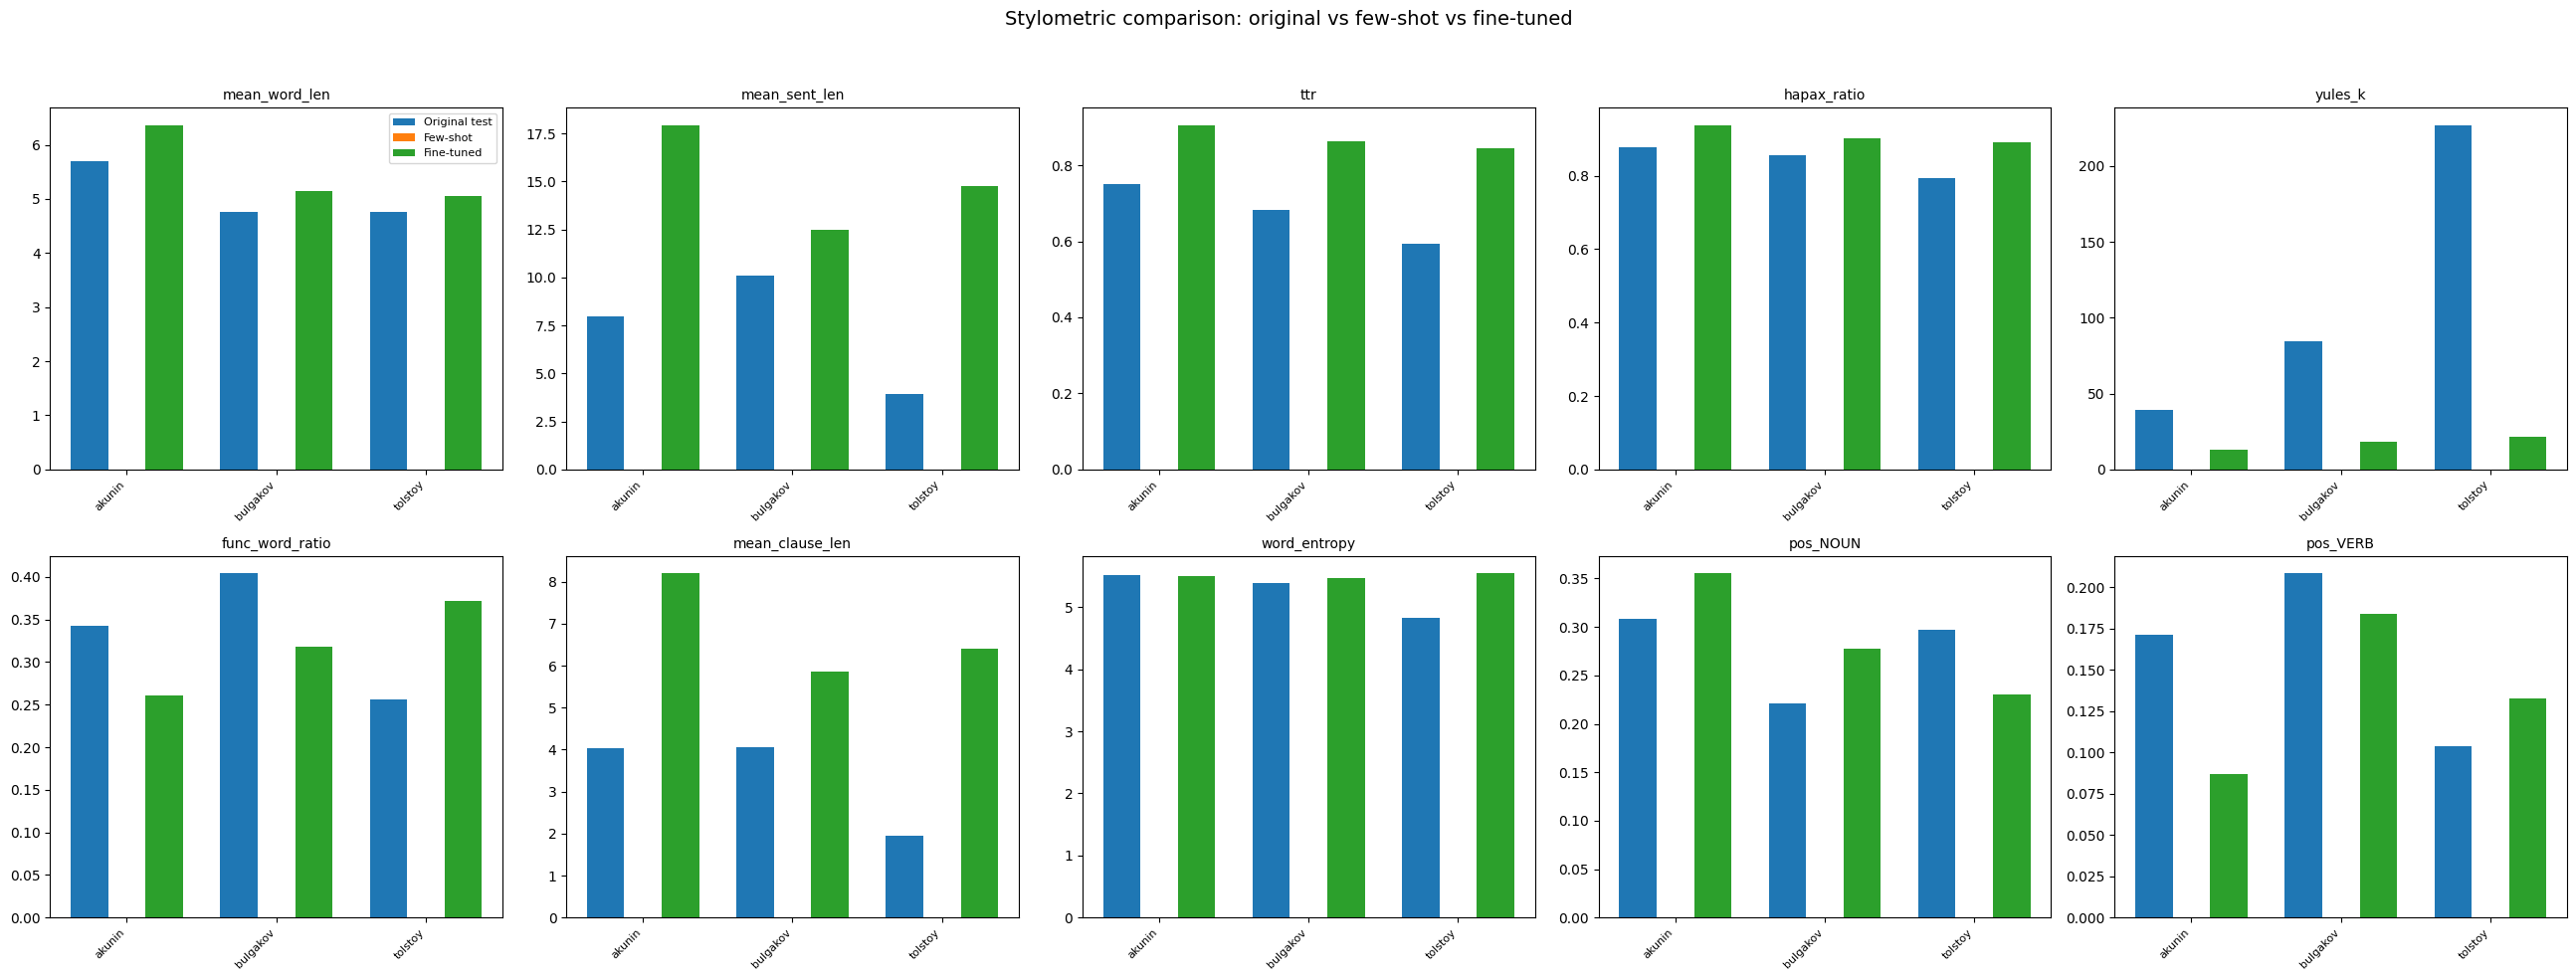

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(26, 10))
axes = axes.flatten()
for idx, metric in enumerate(KEY_METRICS):
    ax = axes[idx]
    x = np.arange(len(author_names))
    width = 0.25

    vals_test = [test_metrics[a].get(metric, 0) if test_metrics[a] else 0
                 for a in author_names]
    vals_fs   = [few_shot_metrics[a].get(metric, 0) if few_shot_metrics.get(a) else 0
                 for a in author_names]
    vals_ft   = [finetuned_metrics[a].get(metric, 0) if finetuned_metrics.get(a) else 0
                 for a in author_names]

    ax.bar(x - width, vals_test, width, label='Original test')
    ax.bar(x, vals_fs, width, label='Few-shot')
    ax.bar(x + width, vals_ft,   width, label='Fine-tuned')

    ax.set_title(metric, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([a[:12] for a in author_names], rotation=45, ha='right', fontsize=8)
    if idx == 0:
        ax.legend(fontsize=8)

plt.suptitle('Stylometric comparison: original vs few-shot vs fine-tuned', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(OUT_DIR, 'metrics_comparison.png'), dpi=150)
plt.show()

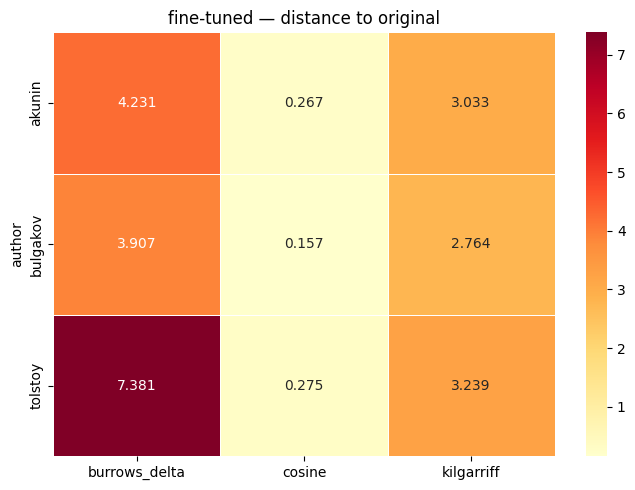

In [ ]:
if len(df_dist) > 0:
    available_methods = [m for m in ['few-shot', 'fine-tuned']
                         if (df_dist['method'] == m).any()]

    if not available_methods:
        print('No distance data available for either method — skipping heatmap.')
    else:
        fig, axes = plt.subplots(1, len(available_methods),
                                 figsize=(7 * len(available_methods), 5),
                                 squeeze=False)
        axes = axes.flatten()

        for i, method in enumerate(available_methods):
            sub = df_dist[df_dist['method'] == method].set_index('author')
            vals = sub[['burrows_delta', 'cosine', 'kilgarriff']].apply(
                pd.to_numeric, errors='coerce'
            )
            # drop rows where all three metrics are NaN
            vals = vals.dropna(how='all')

            if vals.empty:
                axes[i].set_title(f'{method} — no valid data')
                axes[i].text(0.5, 0.5, 'No valid metrics',
                             ha='center', va='center', transform=axes[i].transAxes)
                continue

            sns.heatmap(vals, annot=True, fmt='.3f', cmap='YlOrRd',
                        ax=axes[i], linewidths=0.5)
            axes[i].set_title(f'{method} — distance to original')

        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, 'distance_heatmap.png'), dpi=150)
        plt.show()
else:
    print('df_dist is empty — no distances were computed.')

In [ ]:
RADAR_METRICS = ['mean_word_len','mean_sent_len','ttr','func_word_ratio',
                 'yules_k','word_entropy','pos_NOUN','pos_VERB']


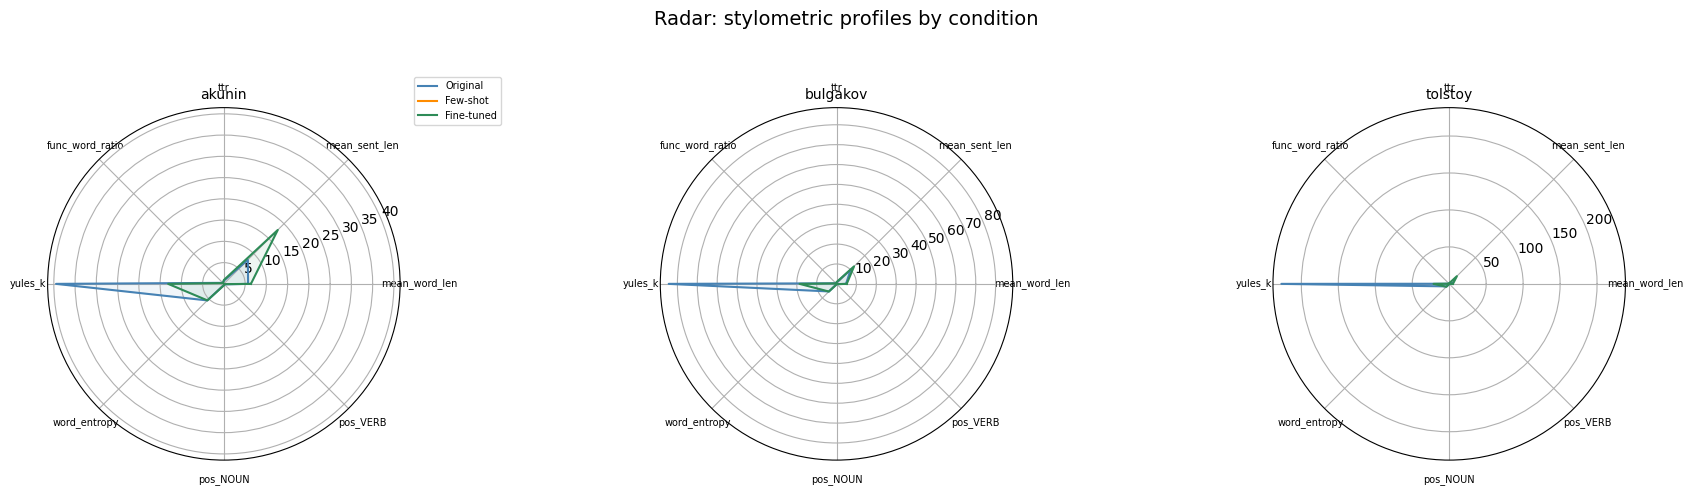

In [ ]:
def radar_plot(author, ax):
    labels = RADAR_METRICS
    n_vars = len(labels)
    angles  = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
    angles += angles[:1]

    def get_vals(d):
        v = [d.get(m, 0) for m in labels] if d else [0]*n_vars
        return v + v[:1]

    for vals, lab, color in [
        (get_vals(test_metrics[author]),      'Original',   'steelblue'),
        (get_vals(few_shot_metrics.get(author)), 'Few-shot', 'darkorange'),
        (get_vals(finetuned_metrics.get(author)), 'Fine-tuned','seagreen'),
    ]:
        ax.plot(angles, vals, label=lab, color=color)
        ax.fill(angles, vals, alpha=0.08, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_title(author, fontsize=10)

ncols = min(len(author_names), 4)
nrows = (len(author_names) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows),
                         subplot_kw=dict(polar=True))
if nrows * ncols == 1:
    axes = np.array([axes])
axes = axes.flatten()
for i, author in enumerate(author_names):
    radar_plot(author, axes[i])
    if i == 0:
        axes[i].legend(loc='upper right', fontsize=7, bbox_to_anchor=(1.3, 1.1))
for j in range(len(author_names), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Radar: stylometric profiles by condition', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(os.path.join(OUT_DIR, 'radar_comparison.png'), dpi=150)
plt.show()

In [ ]:
print(f'\nAll plots and data saved to {OUT_DIR}')


All plots and data saved to /content/drive/MyDrive/texts_project/output


А вот это интерактивная ячейка! Давайте выберем по Burrows' Delta самую похожую на оригинал модельку и попробуем что-нибудь погенерировать с ее помощью.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from peft import PeftModel
import textwrap, json, gc

In [ ]:
if len(df_dist) > 0:
    ft_rows = df_dist[df_dist['method'] == 'fine-tuned'].copy()
    ft_rows['burrows_delta'] = pd.to_numeric(ft_rows['burrows_delta'], errors='coerce')
    ft_rows = ft_rows.dropna(subset=['burrows_delta'])

    if len(ft_rows) > 0:
        best_author = ft_rows.loc[ft_rows['burrows_delta'].idxmin(), 'author']
    else:
        best_author = author_names[0]
else:
    best_author = author_names[0]

print(f'Best adapter (lowest Burrows δ to original): {best_author}')

Но все равно сделаем дропдаун с выбором разных моделек:

In [ ]:
available_adapters = {}
for author in author_names:
    adapter_path = os.path.join(MODEL_DIR, author.replace(' ', '_'))
    if os.path.isdir(adapter_path):
        available_adapters[author] = adapter_path

if not available_adapters:
    raise FileNotFoundError(f'No adapters found in {MODEL_DIR}')

Подгружаем модельку и адаптер

In [ ]:
loaded = {'author': None, 'model': None}

def load_adapter(author):
    if loaded['model'] is not None:
        del loaded['model']
        torch.cuda.empty_cache()
        gc.collect()

    status_out.clear_output()
    with status_out:
        print(f'Loading base model + adapter for "{author}"...')

    base = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=quant_config,
        device_map='auto',
    )
    model = PeftModel.from_pretrained(base, available_adapters[author])
    model.eval()

    loaded['author'] = author
    loaded['model'] = model

    with status_out:
        clear_output()
        print(f'Loaded: {author}')

Пишем функцию для генерации текста

In [ ]:
def generate_text(prompt, max_tokens, temperature, top_p, rep_penalty):
    model = loaded['model']
    enc = tokenizer(prompt, return_tensors='pt', truncation=False)
    input_ids = enc['input_ids']

    max_prompt = model.config.max_position_embeddings - max_tokens
    if input_ids.shape[1] > max_prompt:
        input_ids = input_ids[:, -max_prompt:]

    input_ids = input_ids.to(model.device)

    with torch.no_grad():
        out = model.generate(
            input_ids,
            max_new_tokens=max_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=top_p,
            repetition_penalty=rep_penalty,
        )

    gen_ids = out[0, input_ids.shape[1]:]
    return tokenizer.decode(gen_ids, skip_special_tokens=True)


Теперь строим интерфейс в колабе:

In [ ]:
style_tag = """
<style>
.gen-output {
    background: #f8f9fa; border: 1px solid #dee2e6; border-radius: 8px;
    padding: 16px; margin-top: 8px; font-family: Georgia, serif;
    font-size: 14px; line-height: 1.7; white-space: pre-wrap;
    max-height: 500px; overflow-y: auto;
    color: #1a1a1a;
}
.gen-label {
    font-weight: 600; color: #1a1a1a; margin-bottom: 4px; font-size: 13px;
}
</style>
"""
display(HTML(style_tag))

author_dropdown = widgets.Dropdown(
    options=list(available_adapters.keys()),
    value=best_author,
    description='Author:',
    layout=widgets.Layout(width='50%'),
)

prompt_area = widgets.Textarea(
    value='Однажды, в самый обычный день, произошло нечто необъяснимое.\n\n',
    description='Prompt:',
    layout=widgets.Layout(width='90%', height='120px'),
)

max_tokens_slider = widgets.IntSlider(
    value=300, min=50, max=700, step=50,
    description='Max tokens:', style={'description_width': 'initial'},
    layout=widgets.Layout(width='45%'),
)

temp_slider = widgets.FloatSlider(
    value=0.85, min=0.1, max=1.5, step=0.05,
    description='Temperature:', style={'description_width': 'initial'},
    layout=widgets.Layout(width='45%'),
)

top_p_slider = widgets.FloatSlider(
    value=0.92, min=0.5, max=1.0, step=0.02,
    description='Top-p:', style={'description_width': 'initial'},
    layout=widgets.Layout(width='45%'),
)

rep_penalty_slider = widgets.FloatSlider(
    value=1.15, min=1.0, max=1.5, step=0.05,
    description='Rep. penalty:', style={'description_width': 'initial'},
    layout=widgets.Layout(width='45%'),
)

generate_btn = widgets.Button(
    description='Generate',
    button_style='primary',
    icon='pencil',
    layout=widgets.Layout(width='150px', height='38px'),
)

clear_btn = widgets.Button(
    description='Clear output',
    button_style='',
    icon='eraser',
    layout=widgets.Layout(width='150px', height='38px'),
)

status_out = widgets.Output()
result_out = widgets.Output()

generation_history = []

def on_author_change(change):
    if change['new'] != loaded['author']:
        load_adapter(change['new'])

author_dropdown.observe(on_author_change, names='value')

def on_generate(btn):
    if loaded['model'] is None:
        load_adapter(author_dropdown.value)

    generate_btn.disabled = True
    generate_btn.description = 'Generating...'

    try:
        text = generate_text(
            prompt_area.value,
            max_tokens_slider.value,
            temp_slider.value,
            top_p_slider.value,
            rep_penalty_slider.value,
        )
        generation_history.append({
            'author': author_dropdown.value,
            'prompt': prompt_area.value,
            'output': text,
            'params': {
                'max_tokens': max_tokens_slider.value,
                'temperature': temp_slider.value,
                'top_p': top_p_slider.value,
                'rep_penalty': rep_penalty_slider.value,
            },
        })

        with result_out:
            n = len(generation_history)
            display(HTML(
                f'<div class="gen-label">#{n} — {author_dropdown.value} '
                f'(T={temp_slider.value}, top_p={top_p_slider.value})</div>'
                f'<div class="gen-output">{text}</div><br>'
            ))
    finally:
        generate_btn.disabled = False
        generate_btn.description = 'Generate'

def on_clear(btn):
    result_out.clear_output()

generate_btn.on_click(on_generate)
clear_btn.on_click(on_clear)

controls_row1 = widgets.HBox([max_tokens_slider, temp_slider])
controls_row2 = widgets.HBox([top_p_slider, rep_penalty_slider])
buttons_row   = widgets.HBox([generate_btn, clear_btn])

ui = widgets.VBox([
    author_dropdown,
    prompt_area,
    controls_row1,
    controls_row2,
    buttons_row,
    status_out,
    result_out,
])

display(ui)

# Pre-load the best adapter
load_adapter(best_author)

Best adapter (lowest Burrows δ to original): bulgakov


Loading weights:   0%|          | 0/772 [00:00<?, ?it/s]

А теперь давайте посмотрим, сможем ли мы натренировать простую модельку, чтобы она отличала наши нагенерированные тексты.

In [ ]:
from peft import PeftModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import gc, json

Сначала опять берем самую близкую к своему автору модельку и смотрим, сколько у нас в трейне

In [ ]:
if len(df_dist) > 0:
    ft_rows = df_dist[df_dist['method'] == 'fine-tuned'].copy()
    ft_rows['burrows_delta'] = pd.to_numeric(ft_rows['burrows_delta'], errors='coerce')
    ft_rows = ft_rows.dropna(subset=['burrows_delta'])
    best_author = ft_rows.loc[ft_rows['burrows_delta'].idxmin(), 'author'] if len(ft_rows) > 0 else author_names[0]
else:
    best_author = author_names[0]

target = len(splits[best_author]['train']) + len(splits[best_author]['test'])
print(f'Best author: {best_author}')
print(f'Target generated volume: ~{target:,} chars')

Best author: bulgakov
Target generated volume: ~831,605 chars


Теперь напишем несколько вариантов начала нашей истории для генерации

In [ ]:
PROMPT_SEEDS = [
    'Однажды, в самый обычный день, произошло нечто необъяснимое.\n\n',
    'Вечером, когда все уже спали, он вышел на улицу.\n\n',
    'Никто не мог объяснить, почему это случилось именно тогда.\n\n',
    'В тот год зима пришла необычно рано.\n\n',
    'Она открыла дверь и увидела то, чего не ожидала.\n\n',
    'Город просыпался медленно, словно нехотя.\n\n',
    'Разговор, начавшийся так просто, изменил всё.\n\n',
    'На столе лежало письмо без обратного адреса.\n\n',
    'Поезд остановился на станции, которой не было на карте.\n\n',
    'Дождь не прекращался третий день подряд.\n\n',
    'Старый дом на окраине хранил много тайн.\n\n',
    'Утро началось с телефонного звонка.\n\n',
]

Загрузим модельку с адаптером, поставим в эвал

In [156]:
adapter_path = os.path.join(MODEL_DIR, best_author.replace(' ', '_'))
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=quant_config, device_map='auto',
)
model = PeftModel.from_pretrained(model, adapter_path)
model.eval()

Loading weights:   0%|          | 0/772 [00:00<?, ?it/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): XGLMForCausalLM(
      (model): XGLMModel(
        (embed_tokens): XGLMScaledWordEmbedding(256008, 2048, padding_idx=1)
        (embed_positions): XGLMSinusoidalPositionalEmbedding()
        (layers): ModuleList(
          (0-47): 48 x XGLMDecoderLayer(
            (self_attn): XGLMAttention(
              (k_proj): Linear4bit(in_features=2048, out_features=2048, bias=True)
              (v_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=2048, out_features=2048, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=2048, bias=False)
                )
                (lora_embedding

Поставим верхнюю границу количества текста которое мы возьмем для анализа на 50к символов

In [157]:
GEN_CAP=50000

Теперь возьмем 50000 символов булгаковского текста и нагенерируем столько же текста нашей моделькой

In [158]:
collected = []
total = 0
seed_idx = 0

while total < GEN_CAP:
    prompt = PROMPT_SEEDS[seed_idx % len(PROMPT_SEEDS)]
    seed_idx += 1

    enc = tokenizer(prompt, return_tensors='pt', truncation=False)
    input_ids = enc['input_ids'].to(model.device)

    with torch.no_grad():
        out = model.generate(
            input_ids,
            max_new_tokens=GEN_TOKENS,
            do_sample=True,
            temperature=0.85,
            top_p=0.92,
            repetition_penalty=1.15,
        )
    gen_ids = out[0, input_ids.shape[1]:]
    text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()

    if len(text) > 50:
        collected.append(text)
        total += len(text)
        print(f'  chunk {seed_idx}: {len(text)} chars  (total: {total:,}/{GEN_CAP:,})')

del model
torch.cuda.empty_cache()
gc.collect()

generated_corpus = '\n\n'.join(collected)[:GEN_CAP]

  chunk 1: 2138 chars  (total: 2,138/50,000)
  chunk 2: 2021 chars  (total: 4,159/50,000)
  chunk 3: 2076 chars  (total: 6,235/50,000)
  chunk 4: 2195 chars  (total: 8,430/50,000)
  chunk 5: 2088 chars  (total: 10,518/50,000)
  chunk 6: 2047 chars  (total: 12,565/50,000)
  chunk 7: 2228 chars  (total: 14,793/50,000)
  chunk 8: 2174 chars  (total: 16,967/50,000)
  chunk 9: 2117 chars  (total: 19,084/50,000)
  chunk 10: 2030 chars  (total: 21,114/50,000)
  chunk 11: 2093 chars  (total: 23,207/50,000)
  chunk 12: 2012 chars  (total: 25,219/50,000)
  chunk 13: 2015 chars  (total: 27,234/50,000)
  chunk 14: 2023 chars  (total: 29,257/50,000)
  chunk 15: 2154 chars  (total: 31,411/50,000)
  chunk 16: 2077 chars  (total: 33,488/50,000)
  chunk 17: 2025 chars  (total: 35,513/50,000)
  chunk 18: 2074 chars  (total: 37,587/50,000)
  chunk 19: 2170 chars  (total: 39,757/50,000)
  chunk 20: 2133 chars  (total: 41,890/50,000)
  chunk 21: 2196 chars  (total: 44,086/50,000)
  chunk 22: 2092 chars  (t

In [159]:
CHUNK_SIZE_CLS = 500

In [160]:
real_full = author_full[best_author]
real_trimmed = real_full[:GEN_CAP]
splits[best_author]['train'] = real_trimmed

print(f'\nGenerated: {len(generated_corpus):,} chars')
print(f'Real:      {len(real_trimmed):,} chars  (taken from {len(real_full):,} total)')
with open(os.path.join(OUT_DIR, f'classifier_generated_{best_author}.json'), 'w', encoding='utf-8') as f:
    json.dump({'author': best_author, 'text': generated_corpus}, f, ensure_ascii=False, indent=2)


Generated: 50,000 chars
Real:      50,000 chars  (taken from 833,605 total)


А теперь научим простенький логрег предсказывать принадлежность чанка автору или модельке при доступности метрик (интересно, кто будет самым показательным)

In [161]:
def chunk_text(text, size=CHUNK_SIZE_CLS):
    return [text[i:i + size] for i in range(0, len(text) - size + 1, size)]


In [162]:
def chunks_to_features(chunks, feat_names):
    rows = []
    for ch in chunks:
        m = compute_metrics(ch)
        if m is not None:
            rows.append([m.get(f, 0) for f in feat_names])
    return np.array(rows) if rows else np.empty((0, len(feat_names)))

In [163]:
real_train_chunks = chunk_text(splits[best_author]['train'])
real_test_chunks  = chunk_text(splits[best_author]['test'])


In [174]:
gen_chunks = chunk_text(generated_corpus)
n_gen_train = len(gen_chunks) // 2
gen_train_chunks = gen_chunks[:n_gen_train]
gen_test_chunks  = gen_chunks[n_gen_train:]

real_chunks = chunk_text(splits[best_author]['train'])
n_real_train = len(real_chunks) // 2
real_train_chunks = real_chunks[:n_real_train]
real_test_chunks  = real_chunks[n_real_train:]

print(f'Author: {best_author}')
print(f'Real — train: {len(real_train_chunks)}, test: {len(real_test_chunks)}')
print(f'Gen  — train: {len(gen_train_chunks)},  test: {len(gen_test_chunks)}')

Author: bulgakov
Real — train: 12, test: 13
Gen  — train: 12,  test: 13


In [175]:
X_real_train = chunks_to_features(real_train_chunks, feature_names)
X_real_test  = chunks_to_features(real_test_chunks, feature_names)
X_gen_train  = chunks_to_features(gen_train_chunks, feature_names)
X_gen_test   = chunks_to_features(gen_test_chunks, feature_names)

X_train = np.vstack([X_real_train, X_gen_train])
y_train = np.array([0]*X_real_train.shape[0] + [1]*X_gen_train.shape[0])
X_test  = np.vstack([X_real_test, X_gen_test])
y_test  = np.array([0]*X_real_test.shape[0] + [1]*X_gen_test.shape[0])

perm = np.random.permutation(len(y_train))
X_train, y_train = X_train[perm], y_train[perm]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [176]:
clf = LogisticRegression(max_iter=2000, C=1.0, solver='lbfgs')
clf.fit(X_train_s, y_train)

LogisticRegression(max_iter=2000)

In [177]:
y_pred = clf.predict(X_test_s)

In [178]:
print(f'\nClassification report (0 = real, 1 = generated):')
print(classification_report(y_test, y_pred, target_names=['real', 'generated'], digits=3))


Classification report (0 = real, 1 = generated):
              precision    recall  f1-score   support

        real      1.000     1.000     1.000        13
   generated      1.000     1.000     1.000        13

    accuracy                          1.000        26
   macro avg      1.000     1.000     1.000        26
weighted avg      1.000     1.000     1.000        26



In [179]:
cm = confusion_matrix(y_test, y_pred)
print(f'Confusion matrix:')
print(f'                 pred_real  pred_gen')
print(f'    actual_real  {cm[0,0]:>9}  {cm[0,1]:>8}')
print(f'    actual_gen   {cm[1,0]:>9}  {cm[1,1]:>8}')

Confusion matrix:
                 pred_real  pred_gen
    actual_real         13         0
    actual_gen           0        13


посмотрим на коэффициенты

In [180]:
coefs = pd.Series(clf.coef_[0], index=feature_names)
coefs_sorted = coefs.abs().sort_values(ascending=False)

print(f'\nAll features by |coefficient| (positive → generated, negative → real):')
print(f'{"Feature":<25} {"Coef":>10} {"Direction":>12}')
print('-' * 50)
for feat in coefs_sorted.index:
    c = coefs[feat]
    direction = '→ generated' if c > 0 else '→ real'
    print(f'{feat:<25} {c:>+10.4f} {direction:>12}')


All features by |coefficient| (positive → generated, negative → real):
Feature                         Coef    Direction
--------------------------------------------------
word_entropy                 +0.3818  → generated
ttr                          +0.3720  → generated
p_semi                       +0.3214  → generated
pos_INFN                     +0.3190  → generated
mean_clause_len              +0.3161  → generated
p_comma                      -0.3129       → real
std_word_len                 -0.3015       → real
simpsons_d                   +0.2844  → generated
yules_k                      -0.2843       → real
pos_ADVB                     +0.2733  → generated
hapax_ratio                  +0.2425  → generated
fw_на                        -0.2331       → real
fw_и                         -0.2283       → real
fw_не                        -0.2152       → real
fw_в                         -0.2054       → real
func_word_ratio              +0.2043  → generated
fw_с                       

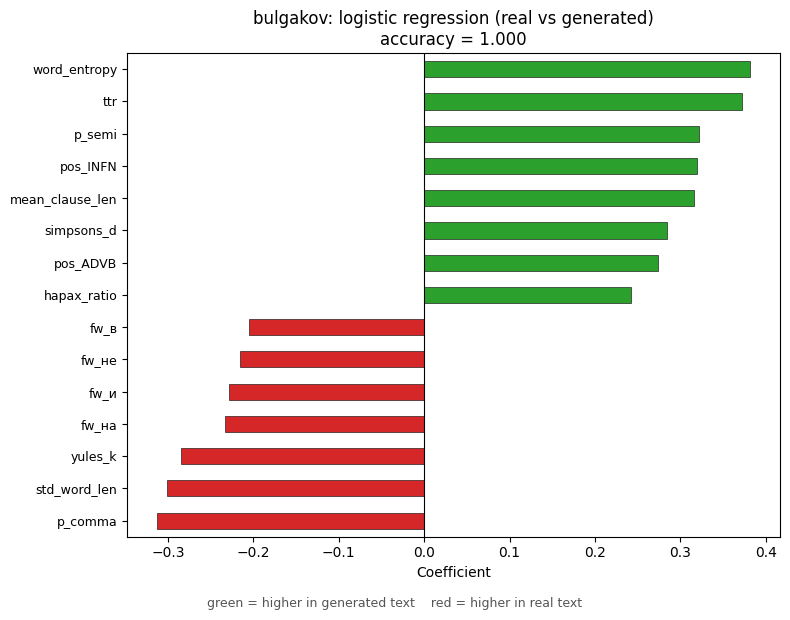

In [181]:
vals = coefs.reindex(coefs_sorted.index[:15]).sort_values()
colors = ['#2ca02c' if v > 0 else '#d62728' for v in vals]

fig, ax = plt.subplots(figsize=(8, 6))
vals.plot.barh(ax=ax, color=colors, edgecolor='black', linewidth=0.4)
ax.set_xlabel('Coefficient')
ax.set_title(
    f'{best_author}: logistic regression (real vs generated)\n'
    f'accuracy = {clf.score(X_test_s, y_test):.3f}',
    fontsize=12,
)
ax.axvline(0, color='black', linewidth=0.8)
ax.tick_params(axis='y', labelsize=9)

fig.text(0.5, -0.02,
         'green = higher in generated text    red = higher in real text',
         ha='center', fontsize=9, color='#555555')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'classifier_coefficients.png'), dpi=150)
plt.show()

Теперь попробуем сделать все то же самое но без метрик

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [ ]:
CHUNK_SIZE_CLS = 2000

In [ ]:
def chunk_text(text, size=CHUNK_SIZE_CLS):
    return [text[i:i + size] for i in range(0, len(text) - size + 1, size)]

In [ ]:
real_chunks = chunk_text(splits[best_author]['train'])
gen_chunks  = chunk_text(generated_corpus)

print(f'Author: {best_author}')
print(f'Real chunks:      {len(real_chunks)}')
print(f'Generated chunks: {len(gen_chunks)}')

In [ ]:
texts  = real_chunks + gen_chunks
labels = np.array([0] * len(real_chunks) + [1] * len(gen_chunks))

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.5, random_state=42, stratify=labels,
)

In [ ]:
# --- TF-IDF on raw text (word + character n-grams) ---
tfidf_word = TfidfVectorizer(
    analyzer='word', max_features=3000, ngram_range=(1, 2),
    sublinear_tf=True,
)
tfidf_char = TfidfVectorizer(
    analyzer='char_wb', max_features=3000, ngram_range=(2, 4),
    sublinear_tf=True,
)

In [183]:
from scipy.sparse import hstack

X_train_w = tfidf_word.fit_transform(X_train)
X_test_w  = tfidf_word.transform(X_test)
X_train_c = tfidf_char.fit_transform(X_train)
X_test_c  = tfidf_char.transform(X_test)

X_train_s = hstack([X_train_w, X_train_c])
X_test_s  = hstack([X_test_w, X_test_c])

print(f'\nFeature matrix: {X_train_s.shape[1]} features '
      f'(word 1-2gram: {X_train_w.shape[1]}, char 2-4gram: {X_train_c.shape[1]})')

clf = LogisticRegression(max_iter=2000, C=1.0, solver='lbfgs')
clf.fit(X_train_s, y_train)

y_pred = clf.predict(X_test_s)

print(f'\nClassification report (0 = real, 1 = generated):')
print(classification_report(y_test, y_pred, target_names=['real', 'generated'], digits=3))

cm = confusion_matrix(y_test, y_pred)
print(f'Confusion matrix:')
print(f'                 pred_real  pred_gen')
print(f'    actual_real  {cm[0,0]:>9}  {cm[0,1]:>8}')
print(f'    actual_gen   {cm[1,0]:>9}  {cm[1,1]:>8}')

word_names = tfidf_word.get_feature_names_out()
char_names = ['char:' + n for n in tfidf_char.get_feature_names_out()]
all_names  = np.concatenate([word_names, char_names])

coefs = pd.Series(clf.coef_[0], index=all_names)
coefs_sorted = coefs.abs().sort_values(ascending=False)

print(f'\nTop 20 features by |coefficient| (positive → generated, negative → real):')
print(f'{"Feature":<30} {"Coef":>10} {"Direction":>12}')
print('-' * 55)
for feat in coefs_sorted.index[:20]:
    c = coefs[feat]
    direction = '→ generated' if c > 0 else '→ real'
    print(f'{feat:<30} {c:>+10.4f} {direction:>12}')

Author: bulgakov
Real chunks:      25
Generated chunks: 25

Feature matrix: 6000 features (word 1-2gram: 3000, char 2-4gram: 3000)

Classification report (0 = real, 1 = generated):
              precision    recall  f1-score   support

        real      1.000     0.846     0.917        13
   generated      0.857     1.000     0.923        12

    accuracy                          0.920        25
   macro avg      0.929     0.923     0.920        25
weighted avg      0.931     0.920     0.920        25

Confusion matrix:
                 pred_real  pred_gen
    actual_real         11         2
    actual_gen           0        12

Top 20 features by |coefficient| (positive → generated, negative → real):
Feature                              Coef    Direction
-------------------------------------------------------
персиков                          -0.2872       → real
она                               +0.1886  → generated
char:сико                         -0.1768       → real
char:сик    

Видим, что качество немного ухудшилось, но в целом осталось на высоте

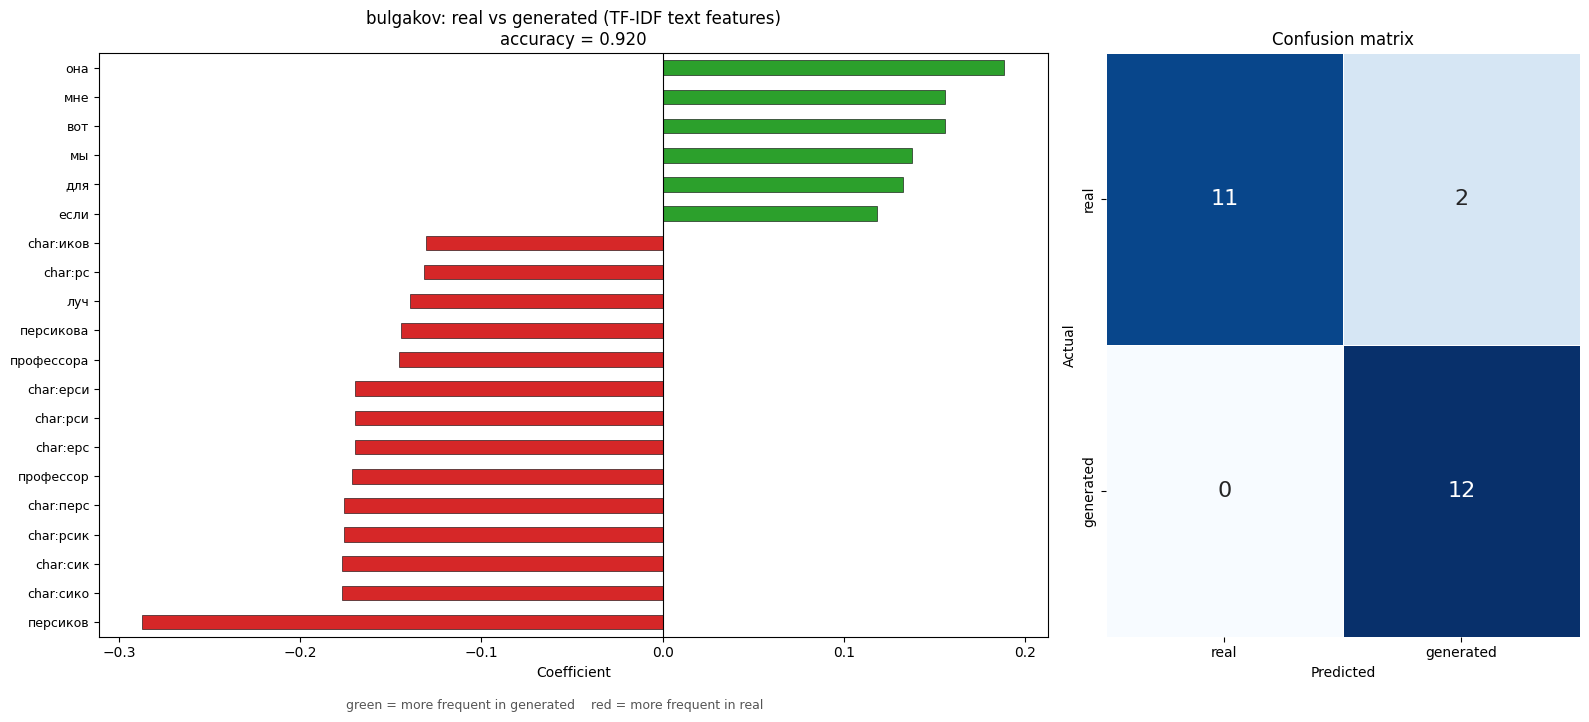

In [185]:
TOP_K = 20
top_feats = coefs.reindex(coefs_sorted.index[:TOP_K]).sort_values()
colors = ['#2ca02c' if v > 0 else '#d62728' for v in top_feats]

fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                         gridspec_kw={'width_ratios': [2, 1]})

ax = axes[0]
top_feats.plot.barh(ax=ax, color=colors, edgecolor='black', linewidth=0.4)
ax.set_xlabel('Coefficient')
ax.set_title(
    f'{best_author}: real vs generated (TF-IDF text features)\n'
    f'accuracy = {clf.score(X_test_s, y_test):.3f}',
    fontsize=12,
)
ax.axvline(0, color='black', linewidth=0.8)
ax.tick_params(axis='y', labelsize=9)

ax2 = axes[1]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['real', 'generated'],
            yticklabels=['real', 'generated'],
            ax=ax2, linewidths=0.5, cbar=False,
            annot_kws={'size': 16})
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_title('Confusion matrix', fontsize=12)

fig.text(0.35, -0.02,
         'green = more frequent in generated    red = more frequent in real',
         ha='center', fontsize=9, color='#555555')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'classifier_coefficients_tfidf.png'), dpi=150)
plt.show()

Видим, что самым сильным предиктором для реальных данных является повторяющееся имя персонажа!